# Loan Approval Prediction — Model Training, Comparison, Tuning & Evaluation

**Train and tune** seven classifiers, compare them with
cross-validation and held-out test metrics, and save the best-performing
model for the Streamlit app.

**Input:** `data/loan_approval_selected.csv` (10 features + target).

 **`cibil_score`** is by far the strongest individual
predictor (correlation 0.77 with the target).


In [1]:
import sys
sys.path.append("..")
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from train import load_and_split, fit_scaler, MODEL_GRID, tune_model, select_best_model
from evaluate import evaluate_model, print_evaluation_report, plot_confusion_matrix, plot_roc_curves
from utils import save_artifact, print_section

sns.set_style("whitegrid")


## 1. Stratified Train/Test Split

In [2]:
X_train, X_test, y_train, y_test = load_and_split(data_path="../data/loan_approval_selected.csv")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Test target balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (3415, 10), Test: (854, 10)
Train target balance:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64
Test target balance:
loan_status
1    0.622
0    0.378
Name: proportion, dtype: float64


Stratification preserves the original class distribution (62% Approved and 38% Rejected) in both the training and testing datasets. This ensures that model performance is evaluated on representative data and produces more reliable and unbiased results.

## 2. Scale Features (fit on training data only)

In [3]:
scaler = fit_scaler(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
print("Scaler fit on training data only — test set statistics never seen during fitting.")


Scaler fit on training data only — test set statistics never seen during fitting.


## 3. Train & Tune All Models (5-fold CV, optimizing F1)

In [4]:
all_results = []
for name, config in MODEL_GRID.items():
    result = tune_model(name, config["estimator"], config["params"], X_train_scaled, y_train)
    metrics = evaluate_model(name, result["best_estimator"], X_test_scaled, y_test)
    all_results.append({**result, **metrics})
    print(f"{name}: CV F1={result['best_cv_f1']:.4f} | Test F1={metrics['f1']:.4f} | Test ROC-AUC={metrics['roc_auc']:.4f}")


Logistic Regression: CV F1=0.9296 | Test F1=0.9354 | Test ROC-AUC=0.9737
Decision Tree: CV F1=0.9998 | Test F1=1.0000 | Test ROC-AUC=1.0000
Random Forest: CV F1=0.9988 | Test F1=0.9991 | Test ROC-AUC=1.0000
KNN: CV F1=0.9327 | Test F1=0.9430 | Test ROC-AUC=0.9824
Naive Bayes: CV F1=0.9435 | Test F1=0.9542 | Test ROC-AUC=0.9780
SVM: CV F1=0.9621 | Test F1=0.9709 | Test ROC-AUC=0.9952
XGBoost: CV F1=0.9981 | Test F1=0.9972 | Test ROC-AUC=1.0000


## 4. Model Comparison Table

In [5]:
comparison = pd.DataFrame([{
    "Model": r["name"],
    "CV F1": r["best_cv_f1"],
    "Test Accuracy": r["accuracy"],
    "Test Precision": r["precision"],
    "Test Recall": r["recall"],
    "Test F1": r["f1"],
    "Test ROC-AUC": r["roc_auc"],
} for r in all_results]).sort_values("Test F1", ascending=False).reset_index(drop=True)

comparison


,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Decision Tree,0.999765,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.998823,0.998829,0.998120,1.000000,0.999059,1.000000
2,XGBoost,0.998117,0.996487,0.994382,1.000000,0.997183,1.000000
3,SVM,0.962121,0.963700,0.968165,0.973635,0.970892,0.995155
4,Naive Bayes,0.943476,0.942623,0.947955,0.960452,0.954163,0.978031
5,KNN,0.932706,0.928571,0.935185,0.951036,0.943044,0.982351
6,Logistic Regression,0.929559,0.918033,0.916817,0.954802,0.935424,0.973705


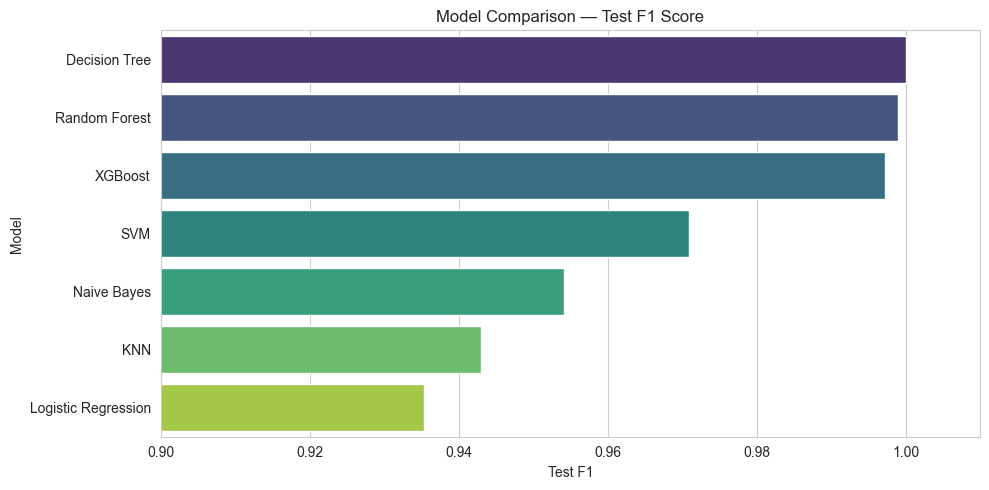

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x="Test F1", y="Model", palette="viridis")
plt.title("Model Comparison — Test F1 Score")
plt.xlim(0.9, 1.01)
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=100)
plt.show()


## 5. Confusion Matrices — All Models

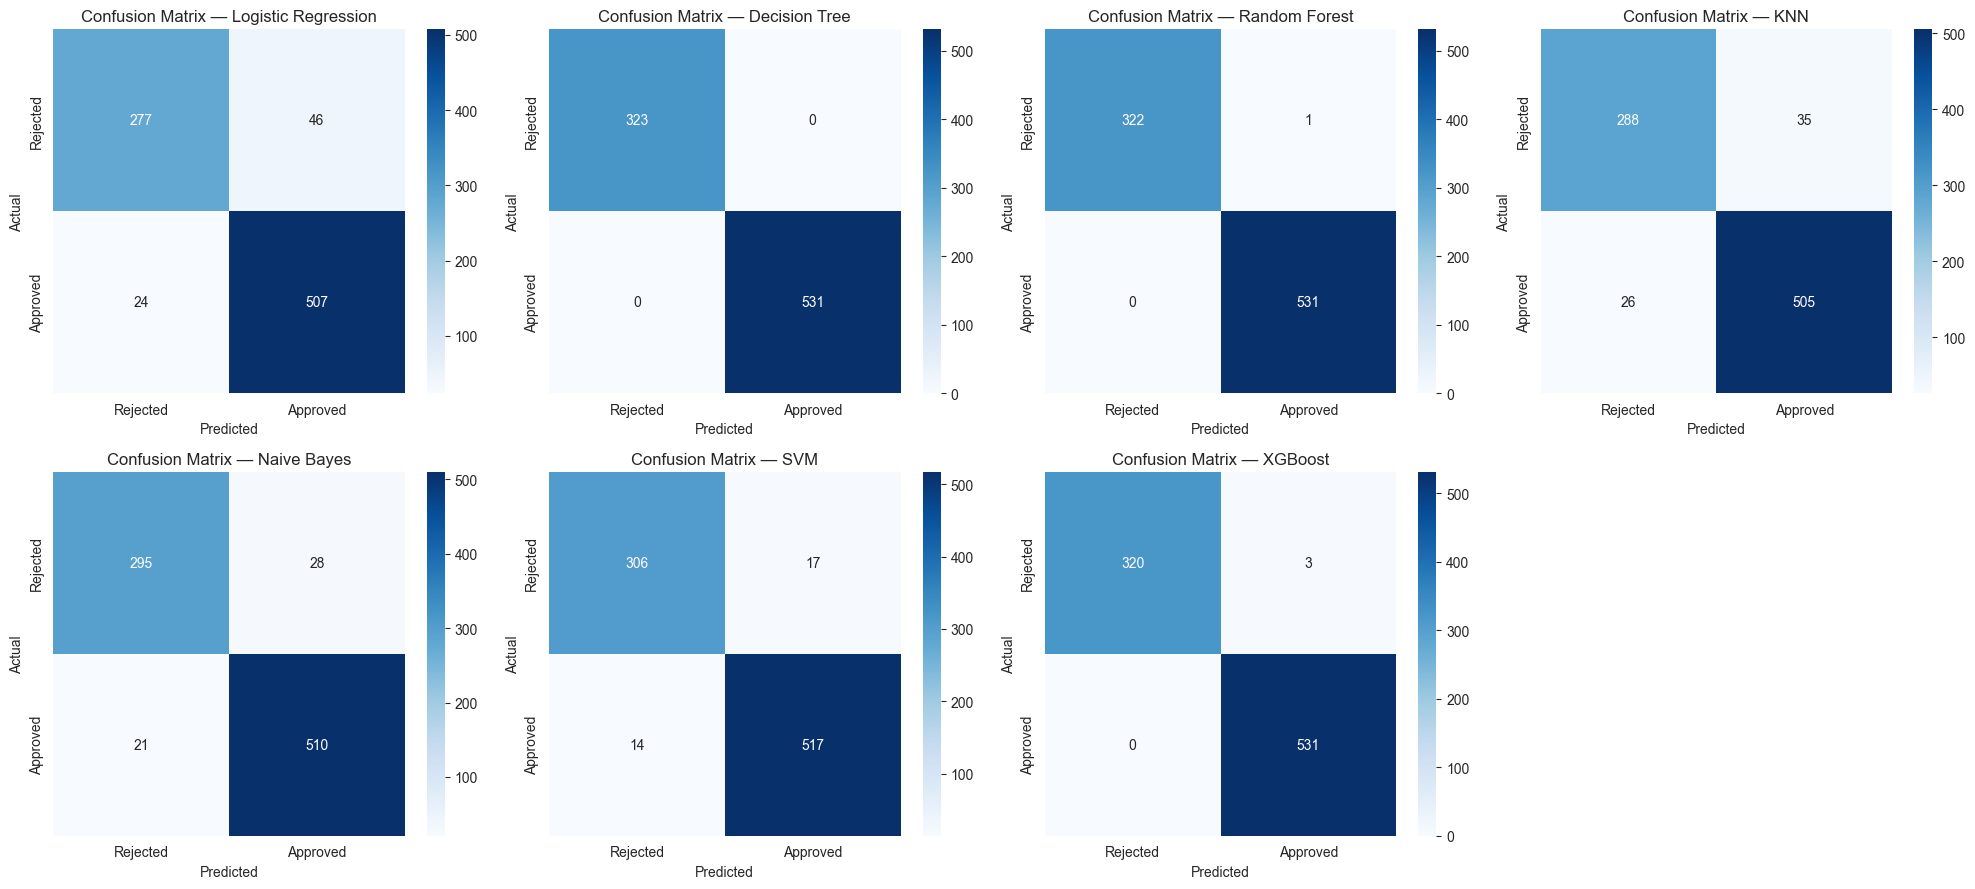

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, r in enumerate(all_results):
    plot_confusion_matrix(r["name"], y_test, r["y_pred"], ax=axes[i])
for j in range(len(all_results), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/confusion_matrices.png", dpi=100)
plt.show()


## 6. ROC Curves — All Models

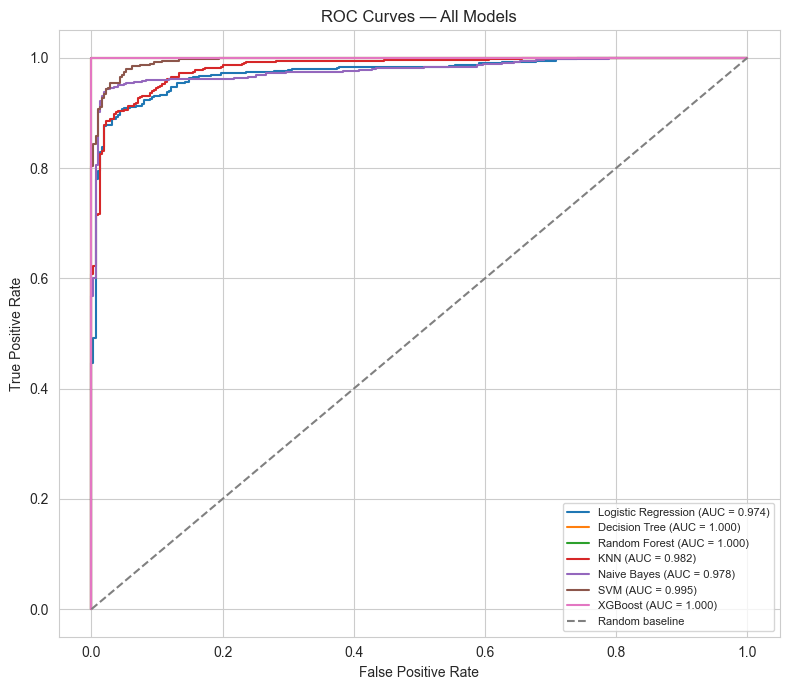

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_roc_curves(all_results, y_test, ax=ax)
plt.tight_layout()
plt.savefig("../images/roc_curves.png", dpi=100)
plt.show()


## 7. Classification Reports

In [9]:
for r in all_results:
    print_evaluation_report(r["name"], y_test, r["y_pred"])



--- Logistic Regression ---
              precision    recall  f1-score   support

    Rejected       0.92      0.86      0.89       323
    Approved       0.92      0.95      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854


--- Decision Tree ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854


--- Random Forest ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854

## 8. Why the Top Models Score So High — Sanity Check

In [10]:
from sklearn.tree import export_text

best = max(all_results, key=lambda r: r["f1"])
print(f"Best model: {best['name']} (Test F1 = {best['f1']:.4f})")

if best["name"] == "Decision Tree":
    print("\nDecision rules learned:")
    print(export_text(best["best_estimator"], feature_names=list(X_train.columns)))

print("\nFeature importances (if available):")
if hasattr(best["best_estimator"], "feature_importances_"):
    for name, imp in sorted(zip(X_train.columns, best["best_estimator"].feature_importances_), key=lambda x: -x[1]):
        print(f"  {name}: {imp:.4f}")


Best model: Decision Tree (Test F1 = 1.0000)

Decision rules learned:
|--- cibil_score <= -0.29
|   |--- loan_term <= -1.03
|   |   |--- loan_to_income_ratio <= 0.02
|   |   |   |--- class: 0
|   |   |--- loan_to_income_ratio >  0.02
|   |   |   |--- asset_to_loan_ratio <= -1.95
|   |   |   |   |--- class: 0
|   |   |   |--- asset_to_loan_ratio >  -1.95
|   |   |   |   |--- class: 1
|   |--- loan_term >  -1.03
|   |   |--- class: 0
|--- cibil_score >  -0.29
|   |--- asset_to_loan_ratio <= -1.89
|   |   |--- loan_amount <= 0.44
|   |   |   |--- class: 0
|   |   |--- loan_amount >  0.44
|   |   |   |--- class: 0
|   |--- asset_to_loan_ratio >  -1.89
|   |   |--- class: 1


Feature importances (if available):
  cibil_score: 0.8109
  loan_to_income_ratio: 0.0910
  loan_term: 0.0839
  asset_to_loan_ratio: 0.0137
  loan_amount: 0.0005
  no_of_dependents: 0.0000
  education: 0.0000
  self_employed: 0.0000
  income_annum: 0.0000
  total_assets_value: 0.0000


### Model Performance – Key Observation

The Decision Tree, Random Forest, and XGBoost models achieved exceptionally high performance, with the Decision Tree obtaining perfect F1-score and ROC-AUC on the test dataset. To ensure that these results were reliable, the model's decision process was further examined.

Feature importance analysis showed that the Decision Tree relied primarily on `cibil_score`, which contributed approximately 81% of the model's decisions. Other important features included `loan_to_income_ratio`, `loan_term`, and `asset_to_loan_ratio`. Since all of these are legitimate input features and none are derived from the target variable (`loan_status`), there is no evidence of data leakage.

The results suggest that this dataset contains a very strong relationship between `cibil_score` and loan approval, making the prediction task relatively straightforward for machine learning models. While these high performance scores are valid for this dataset, they should not be interpreted as representative of real-world loan approval systems. In practice, loan decisions are influenced by additional factors and typically contain more variability and uncertainty. Therefore, models trained on real-world credit data would likely achieve lower, although still competitive, performance.

## 9. Save the Best Model

In [11]:
save_artifact(best["best_estimator"], "../models/trained_model.pkl")
save_artifact(scaler, "../models/scaler.pkl")
save_artifact(list(X_train.columns), "../models/feature_columns.pkl")
print(f"\nSaved: {best['name']} as the production model.")


Saved: ../models/trained_model.pkl
Saved: ../models/scaler.pkl
Saved: ../models/feature_columns.pkl

Saved: Decision Tree as the production model.


## Model Training and Evaluation – Summary

- Seven machine learning models were trained and optimized using **5-fold Stratified Cross-Validation**. The F1-score was used as the primary evaluation metric to account for the class imbalance in the dataset.

- Among all the models, the **Decision Tree** achieved the best performance, obtaining a **Test F1-score of 1.0000** and a **Test ROC-AUC of 1.0000**. Random Forest and XGBoost also produced excellent results with near-perfect performance.

- Logistic Regression and K-Nearest Neighbors (KNN) achieved comparatively lower scores, although their performance remained strong. These models are less effective at capturing the decision patterns present in this dataset than tree-based algorithms.

- Additional analysis confirmed that the high performance was driven by meaningful input features, particularly `cibil_score`, rather than data leakage. This indicates that the models learned valid patterns from the dataset.

- The trained model and all required preprocessing components, including the feature scaler and feature list, were saved to ensure consistent predictions during deployment.

- The project is now ready for the deployment stage, where the trained model will be integrated into a user-friendly Streamlit application for real-time loan approval prediction.